Loading data...
Shape: (90344, 22)
After target creation n = 90344
target_5
1    80280
2     3754
3     1257
4     1320
5     3733
Name: count, dtype: int64
Subsampling to ~5000 rows (stratified by class)...
New n = 5001
Numeric cols: 14 ['LOAIKH', 'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'ID_TIME', 'ORGNBR', 'PARENTORGNBR', 'LAISUAT', 'loan_age_days', 'CURR_BAL_num', 'log1p_CURR_BAL', 'BASE_BAL_num', 'log1p_BASE_BAL', 'curr_base_ratio']
OHE categorical cols: ['MJACCTTYPCD', 'SEX', 'CURRENCYCD', 'DESC_TIME', 'MJACCTTYPDESC']
Freq-encoding cols: ['PHUONG THUC CHO VAY', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY']
Final feature count (num + cat for pipeline): 23
Train/test shapes: (4000, 23) (1001, 23)

Tuning Logistic Regression (fast grid)...
GridSearch done in 32.3s; best_score=0.4028; best_params={'clf__C': 0.01, 'sel__k': 50}

Tuning RandomForest (fast grid)...
GridSearch done in 16.2s; best_score=0.9022; best_params={'clf__max_depth': None, 'clf__n_estimators': 100, 'sel__k': 50}

Tuning Hi

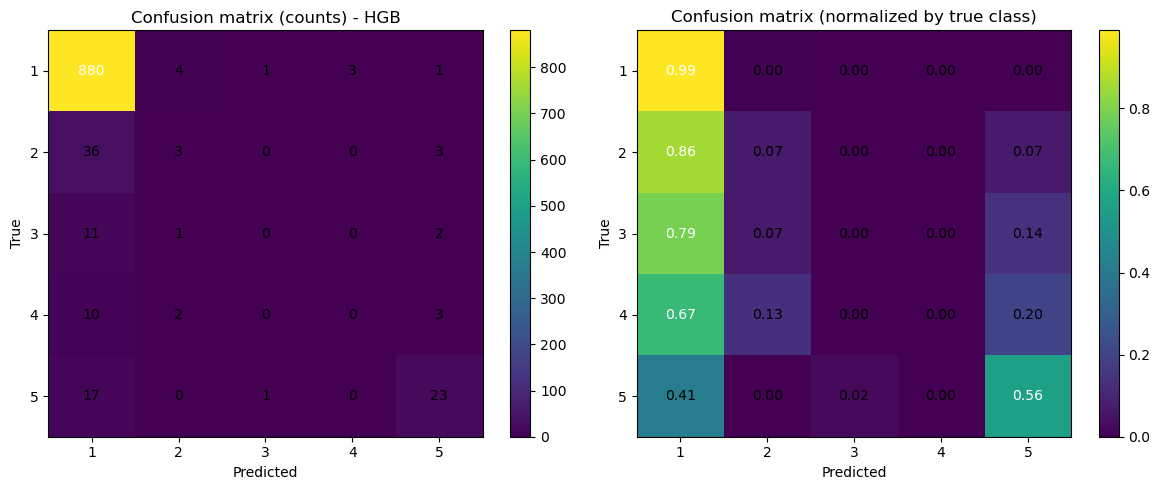

Saved confusion image to: outputs_improved/confusion_HGB.png

Done. Summary file and confusion image in: outputs_improved
If accuracy still low, consider: (1) using ensemble boosting (XGBoost/LightGBM), (2) more feature engineering, (3) addressing label noise or combining classes (ordinal modeling), (4) upsampling rare classes or synthetic oversampling.


In [4]:
"""
Improved multiclass pipeline (target 1..5) with feature engineering, freq-encoding,
SelectKBest, LogisticRegression + RandomForest + HistGradientBoosting, and confusion matrices.

Copy-paste and run. Adjust DATA_PATH, SAMPLE_N, and hyperparams for more exhaustiveness.
"""
import warnings
warnings.filterwarnings("ignore")
import time, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# ---------------- CONFIG ----------------
DATA_PATH = "/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/NGHIÊN CỨU KHOA HỌC/Data_For Midterm and Final Project.xlsx"  # update if needed
SHEET_NAME = 0
RANDOM_STATE = 42
SAMPLE_N = 5000   # set to None to use full dataset (may be slow)
TEST_SIZE = 0.20
TOP_K_CAT = 12    # keep top-K values for OHE; others -> "__other__"
K_FEATURES = 120  # number of features to keep after SelectKBest (tweak)
OUTDIR = "outputs_improved"
os.makedirs(OUTDIR, exist_ok=True)

# ---------------- Load + create 5-class target ----------------
print("Loading data...")
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print("Shape:", df.shape)
# robust parse for NHOMNOMOI -> integer 1..5
def to_group_int(x):
    try:
        if pd.isna(x): return np.nan
        if isinstance(x, (int, np.integer)): return int(x)
        f = float(x)
        if np.isfinite(f): return int(f)
    except Exception:
        pass
    s = str(x)
    import re
    m = re.search(r'([1-5])', s)
    if m: return int(m.group(1))
    return np.nan

df['target_5'] = df.get('NHOMNOMOI').apply(to_group_int)
df = df[df['target_5'].between(1,5)].copy()
df['target_5'] = df['target_5'].astype(int)
print("After target creation n =", len(df))
print(df['target_5'].value_counts().sort_index())

# ---------------- Feature engineering ----------------
# Parse dates if present and create loan_age (days) using NGAYDENHAN or snapshot
for c in ['OPEN_DATE','NGAYDENHAN']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

if 'OPEN_DATE' in df.columns:
    if 'NGAYDENHAN' in df.columns and df['NGAYDENHAN'].notna().any():
        snapshot = df['NGAYDENHAN'].max()
    else:
        snapshot = df['OPEN_DATE'].max()
    df['loan_age_days'] = ((df['NGAYDENHAN'].fillna(snapshot) - df['OPEN_DATE']).dt.total_seconds() / 86400.0).fillna(0.0)
else:
    # fallback: make loan_age 0
    df['loan_age_days'] = 0.0

# numeric transformations for balances
for bal in ['CURR_BAL','BASE_BAL']:
    if bal in df.columns:
        df[f'{bal}_num'] = pd.to_numeric(df[bal].fillna(0), errors='coerce').fillna(0.0)
        df[f'log1p_{bal}'] = np.log1p(df[f'{bal}_num'])
# ratio
if 'CURR_BAL_num' in df.columns and 'BASE_BAL_num' in df.columns:
    # avoid divide by zero
    df['curr_base_ratio'] = df['CURR_BAL_num'] / (1.0 + df['BASE_BAL_num'])

# create some simple dummies from text cols if exist (e.g., SEX)
if 'SEX' in df.columns:
    df['SEX'] = df['SEX'].fillna('missing').astype(str)

# ---------------- Candidate features ----------------
exclude = {'NHOMNOMOI','NHOMNO','NHOMNO_TCBS','OPEN_DATE','NGAYDENHAN','target_5'}
candidate_cols = [c for c in df.columns if c not in exclude]
# remove columns with all-NA or single unique value
candidate_cols = [c for c in candidate_cols if df[c].nunique(dropna=False) > 1]

# ---------------- Subsample stratified if requested ----------------
if SAMPLE_N is not None and SAMPLE_N < len(df):
    print(f"Subsampling to ~{SAMPLE_N} rows (stratified by class)...")
    # compute fraction
    frac = SAMPLE_N / len(df)
    df = df.groupby('target_5', group_keys=False).apply(lambda x: x.sample(frac=min(1.0, frac), random_state=RANDOM_STATE)).reset_index(drop=True)
    print("New n =", len(df))
# Recompute candidate columns (in case subsample changed types)
candidate_cols = [c for c in candidate_cols if c in df.columns]

# ---------------- Split numeric / categorical ----------------
num_cols = df[candidate_cols].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in candidate_cols if c not in num_cols]

# Cap cardinality for categorical columns (map rare -> "__other__")
for c in cat_cols:
    df[c] = df[c].fillna('missing').astype(str)
    topk = df[c].value_counts().nlargest(TOP_K_CAT).index
    df[c] = df[c].where(df[c].isin(topk), other='__other__')

# move high-cardinality categorical to freq-encoded list
freq_encode_cols = [c for c in cat_cols if df[c].nunique() > 8]  # heuristic
ohe_cols = [c for c in cat_cols if c not in freq_encode_cols]

print("Numeric cols:", len(num_cols), num_cols[:20])
print("OHE categorical cols:", ohe_cols)
print("Freq-encoding cols:", freq_encode_cols)

# Apply frequency encoding (map category -> relative frequency)
for c in freq_encode_cols:
    vc = df[c].value_counts(normalize=True)
    df[f'freqenc_{c}'] = df[c].map(vc).fillna(0.0)
    # keep new numeric feature
    num_cols.append(f'freqenc_{c}')

# drop original freq-encoded columns from cat_cols
cat_cols = ohe_cols

# Final feature set
feature_cols = num_cols + cat_cols
print("Final feature count (num + cat for pipeline):", len(feature_cols))

# ---------------- Train/test split ----------------
X = df[feature_cols].copy()
y = df['target_5'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE,
                                                    stratify=y, random_state=RANDOM_STATE)
print("Train/test shapes:", X_train.shape, X_test.shape)

# ---------------- Preprocessor ----------------
def make_ohe(**kwargs):
    try:
        return OneHotEncoder(sparse=False, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse_output=False, **kwargs)

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
ohe = make_ohe(handle_unknown='ignore')
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('ohe', ohe, cat_cols)
], remainder='drop')

# ---------------- Feature selection (SelectKBest) ----------------
selector = SelectKBest(score_func=mutual_info_classif, k=min(K_FEATURES, 1000))  # will be inside final pipeline

# ---------------- Build pipelines for models ----------------
# Logistic Regression pipeline
pipe_lr = Pipeline([('pre', preprocessor), ('sel', selector),
                    ('clf', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000,
                                               class_weight='balanced', random_state=RANDOM_STATE))])

# Random Forest pipeline
pipe_rf = Pipeline([('pre', preprocessor), ('sel', selector),
                    ('clf', RandomForestClassifier(n_jobs=-1, class_weight='balanced', random_state=RANDOM_STATE))])

# HistGradientBoosting pipeline (no class_weight param in some versions)
pipe_hgb = Pipeline([('pre', preprocessor), ('sel', selector),
                     ('clf', HistGradientBoostingClassifier(random_state=RANDOM_STATE))])

# ---------------- Quick hyperparam grids (small) ----------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_grid_lr = {
    'sel__k': [min(50, K_FEATURES), min(120, K_FEATURES), min(300, K_FEATURES)],
    'clf__C': [0.01, 0.1, 1.0]
}
param_grid_rf = {
    'sel__k': [min(50, K_FEATURES), min(120, K_FEATURES)],
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [6, 12, None]
}
param_grid_hgb = {
    'sel__k': [min(50, K_FEATURES), min(120, K_FEATURES)],
    # HistGradientBoosting hyperparams: learning_rate, max_iter
    'clf__max_iter': [100, 200],
    'clf__learning_rate': [0.05, 0.1]
}

# ---------------- Helper to run GridSearch (fast) ----------------
def run_grid(pipe, param_grid, X_tr, y_tr, cv, n_jobs=-1, verbose=1):
    gs = GridSearchCV(pipe, param_grid, scoring='accuracy', cv=cv, n_jobs=n_jobs, verbose=verbose)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    t = time.time() - t0
    print(f"GridSearch done in {t:.1f}s; best_score={gs.best_score_:.4f}; best_params={gs.best_params_}")
    return gs

# ---------------- Run tuning for each model (you can comment out some to save time) ----------------
print("\nTuning Logistic Regression (fast grid)...")
gs_lr = run_grid(pipe_lr, param_grid_lr, X_train, y_train, cv=cv, n_jobs=-1, verbose=0)

print("\nTuning RandomForest (fast grid)...")
gs_rf = run_grid(pipe_rf, param_grid_rf, X_train, y_train, cv=cv, n_jobs=-1, verbose=0)

print("\nTuning HistGradientBoosting (fast grid)...")
try:
    gs_hgb = run_grid(pipe_hgb, param_grid_hgb, X_train, y_train, cv=cv, n_jobs=-1, verbose=0)
except Exception as e:
    print("HGB Grid failed or not available:", e)
    gs_hgb = None

# ---------------- Evaluate best models on test set ----------------
models_to_compare = []
if gs_lr:
    models_to_compare.append(('LogReg', gs_lr.best_estimator_))
if gs_rf:
    models_to_compare.append(('RF', gs_rf.best_estimator_))
if gs_hgb and gs_hgb.best_estimator_:
    models_to_compare.append(('HGB', gs_hgb.best_estimator_))

best_results = []
for name, model in models_to_compare:
    print(f"\nEvaluating {name} on test set...")
    t0 = time.time()
    y_pred = model.predict(X_test)
    t = time.time() - t0
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, supp = precision_recall_fscore_support(y_test, y_pred, labels=[1,2,3,4,5], zero_division=0)
    print(f"{name} accuracy: {acc:.4f} (inference time {t:.3f}s)")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))
    best_results.append((name, acc, prec, rec, f1, supp, y_pred))

# Choose best by accuracy
best_name, best_acc = None, -1.0
best_entry = None
for entry in best_results:
    if entry[1] > best_acc:
        best_acc = entry[1]; best_entry = entry; best_name = entry[0]
print(f"\nBest model by accuracy: {best_name} (acc={best_acc:.4f})")

# ---------------- Confusion matrix for best model ----------------
_, acc, prec, rec, f1, supp, y_pred = best_entry
cm = confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5])
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

# Save summary CSV
summary_df = pd.DataFrame({
    'class':[1,2,3,4,5],
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'support': supp
})
summary_df.to_csv(os.path.join(OUTDIR, "multiclass_summary_improved.csv"), index=False)
print("Saved per-class summary to", os.path.join(OUTDIR, "multiclass_summary_improved.csv"))

# Plot confusion matrices
fig, axes = plt.subplots(1,2, figsize=(12,5))
ax = axes[0]
im = ax.imshow(cm, interpolation='nearest', aspect='auto')
ax.set_title(f'Confusion matrix (counts) - {best_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks(np.arange(5)); ax.set_xticklabels([1,2,3,4,5])
ax.set_yticks(np.arange(5)); ax.set_yticklabels([1,2,3,4,5])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i,j]}", ha='center', va='center', color='w' if cm[i,j]>cm.max()/2 else 'black')
fig.colorbar(im, ax=ax)

ax = axes[1]
im2 = ax.imshow(cm_norm, interpolation='nearest', aspect='auto')
ax.set_title('Confusion matrix (normalized by true class)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks(np.arange(5)); ax.set_xticklabels([1,2,3,4,5])
ax.set_yticks(np.arange(5)); ax.set_yticklabels([1,2,3,4,5])
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha='center', va='center', color='w' if cm_norm[i,j]>cm_norm.max()/2 else 'black')
fig.colorbar(im2, ax=ax)

plt.tight_layout()
out_png = os.path.join(OUTDIR, f"confusion_{best_name}.png")
plt.savefig(out_png, dpi=150)
plt.show()
print("Saved confusion image to:", out_png)

print("\nDone. Summary file and confusion image in:", OUTDIR)
print("If accuracy still low, consider: (1) using ensemble boosting (XGBoost/LightGBM), (2) more feature engineering, (3) addressing label noise or combining classes (ordinal modeling), (4) upsampling rare classes or synthetic oversampling.")


In [1]:
# Vẽ phân phối PD theo các mốc thời gian (30d, 90d, 180d, 365d) để dễ thấy vì sao PD ~0 trong 90d?

# Mô phỏng chiến lược can thiệp sớm (ví dụ: nếu ngân hàng can thiệp top-5% khách hàng theo PD_180d thì giảm được bao nhiêu Expected Loss)